In [2]:
# Phase 3 – Exploratory Data Analysis (EDA)
# Cell 1: Setup + Load Clean Data from Phase 2

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------- Paths ----------------------
PROJECT = Path(r"D:\univercity\omid_project\economics_project")

PHASE2_DATA = PROJECT / "outputs" / "phase2" / "data"
OUT_DIR     = PROJECT / "outputs" / "phase3"

OUT_DATA  = OUT_DIR / "data"
OUT_TAB   = OUT_DIR / "tables"
OUT_FIG   = OUT_DIR / "figures"
OUT_LOG   = OUT_DIR / "logs"

for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 3 – Exploratory Data Analysis | Cell 1")
print("=" * 60)
print(f"Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root  : {PROJECT}")
print(f"Outputs       : {OUT_DIR}")
print()

# ---------------------- Load final clean data ----------------------
df = pd.read_pickle(PHASE2_DATA / "jst_final_clean.pkl")

print("Loaded data from Phase 2:")
print(f"  Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Countries : {df['country'].nunique()}")
print(f"  Year range : {df['year'].min()} – {df['year'].max()}")
print("\nCell 1 completed successfully.")

Phase 3 – Exploratory Data Analysis | Cell 1
Timestamp     : 2026-09-22 10:08:16
Project Root  : D:\univercity\omid_project\economics_project
Outputs       : D:\univercity\omid_project\economics_project\outputs\phase3

Loaded data from Phase 2:
  Shape : 2718 rows × 60 columns
  Countries : 18
  Year range : 1870 – 2020

Cell 1 completed successfully.


Phase 3 – EDA | Cell 2: Distribution Analysis

--- Descriptive Statistics ---
          count         mean           std      min       25%       50%  \
rgdpmad  2666.0     9155.065  7.976190e+03  737.375  2873.048  5477.011   
gdp      2641.0  2454825.561  1.615548e+07    0.000    54.282  1810.926   
cpi      2666.0       41.911  5.690000e+01    0.000     2.526    10.507   
stir     2520.0        4.678  3.333000e+00   -2.000     2.628     4.122   
ltrate   2630.0        5.449  3.158000e+00   -0.525     3.588     4.609   
debtgdp  2489.0        0.543  3.930000e-01    0.019     0.253     0.448   
unemp    1949.0        5.484  4.081000e+00    0.036     2.300     4.600   
iy       2425.0        0.189  6.500000e-02    0.017     0.141     0.194   
money    2518.0  2404281.639  1.645903e+07    0.000    16.303   871.345   
tloans   2465.0  2879900.999  2.143628e+07    0.000    21.237  1173.430   

               75%           max    skew  kurtosis  
rgdpmad  14619.436  4.588757e+04   1.044   

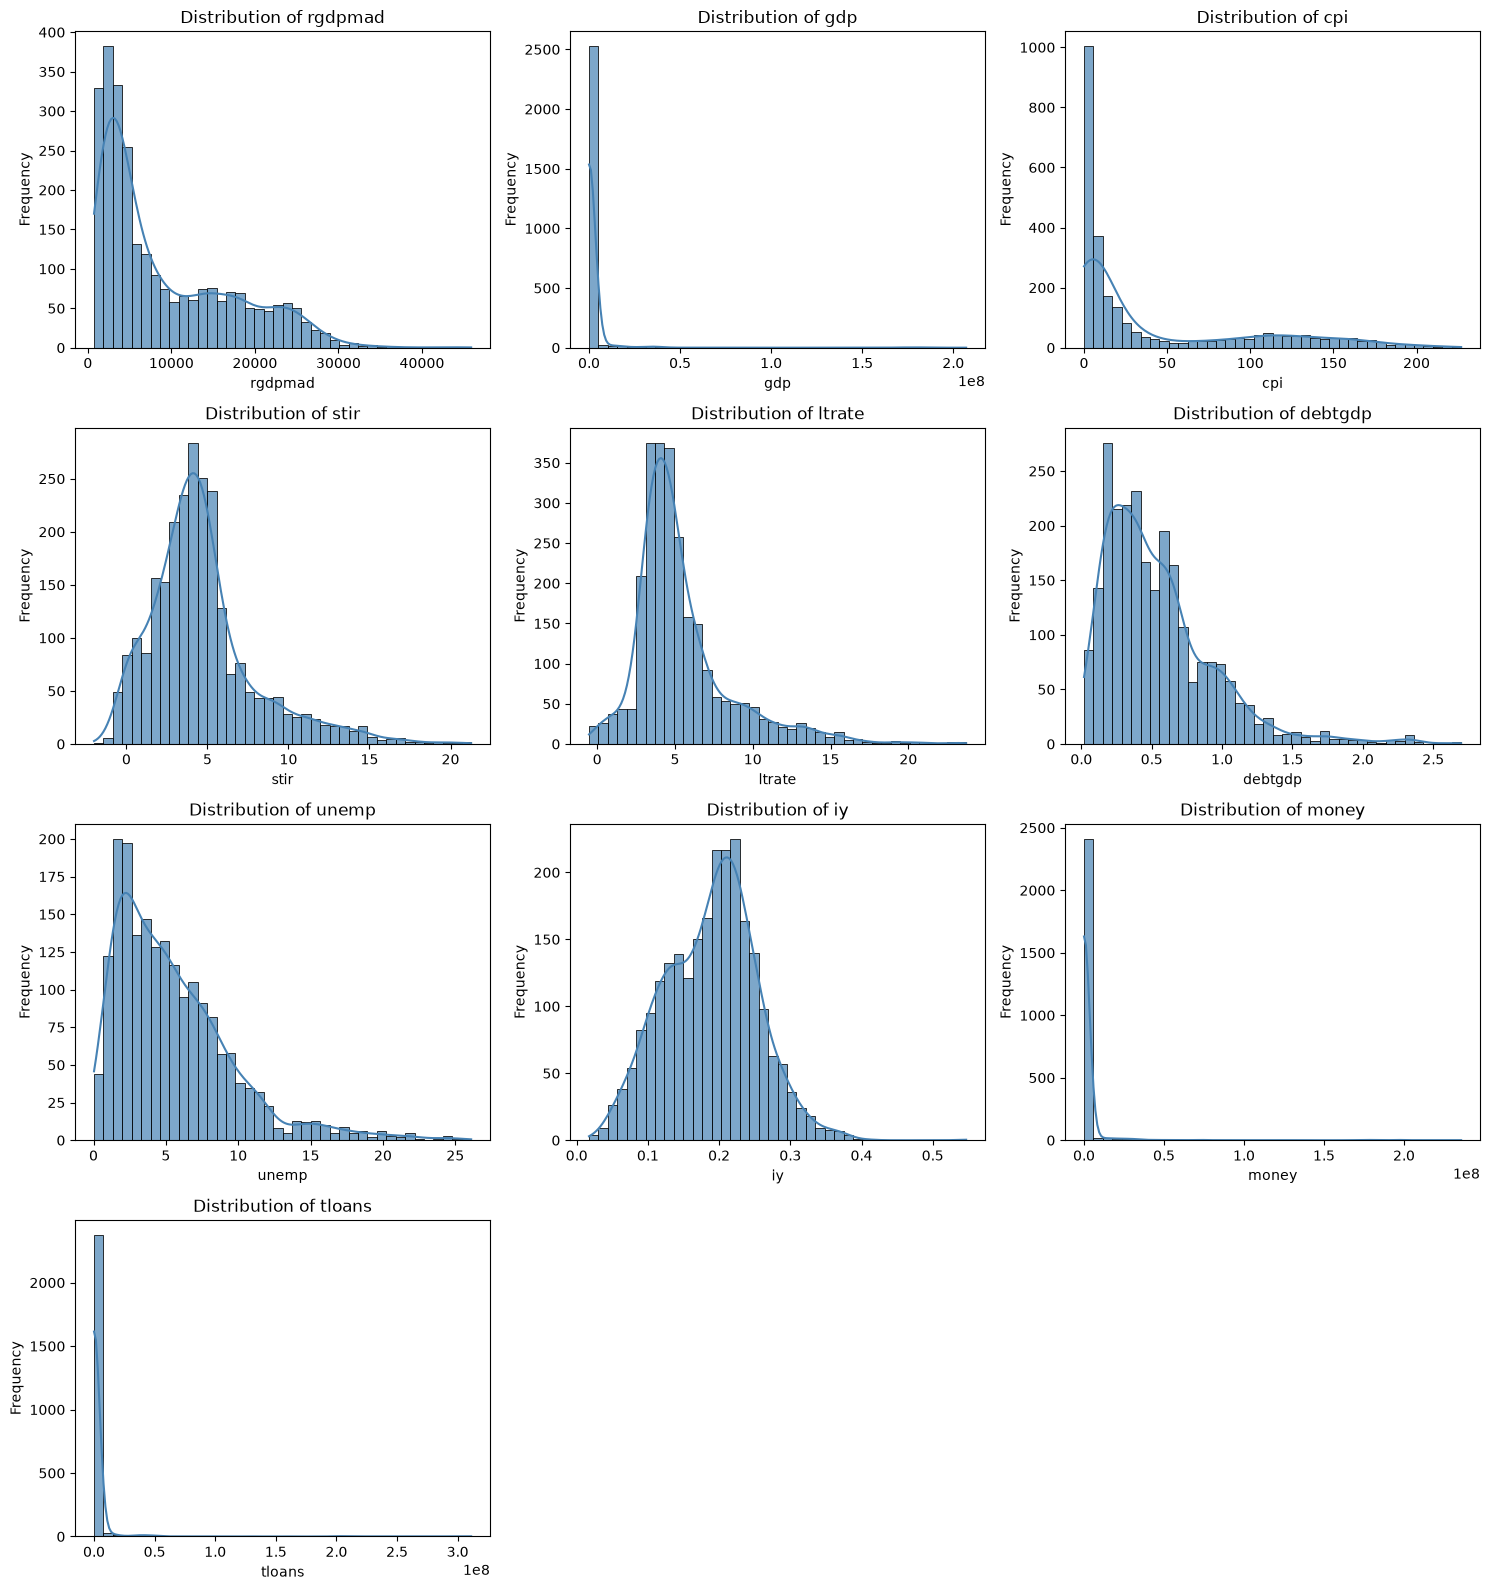

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase3\figures\distributions_hist_kde.png

Cell 2 completed successfully.


In [3]:
# Phase 3 – Exploratory Data Analysis
# Cell 2: Distribution Analysis (Histogram + KDE)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_FIG = PROJECT / "outputs" / "phase3" / "figures"
OUT_TAB = PROJECT / "outputs" / "phase3" / "tables"

df = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "jst_final_clean.pkl")

print("=" * 60)
print("Phase 3 – EDA | Cell 2: Distribution Analysis")
print("=" * 60)

# Key variables for distribution analysis
key_vars = [
    "rgdpmad", "gdp", "cpi", "stir", "ltrate",
    "debtgdp", "unemp", "iy", "money", "tloans"
]
key_vars = [v for v in key_vars if v in df.columns]

# Descriptive statistics
desc = df[key_vars].describe().T
desc["skew"] = df[key_vars].skew()
desc["kurtosis"] = df[key_vars].kurtosis()
print("\n--- Descriptive Statistics ---")
print(desc.round(3))

desc.to_csv(OUT_TAB / "distribution_descriptive_stats.csv")
print(f"\nSaved descriptive stats → {OUT_TAB / 'distribution_descriptive_stats.csv'}")

# ---------------------- Histograms + KDE ----------------------
n_vars = len(key_vars)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    ax = axes[i]
    data = df[var].dropna()
    
    sns.histplot(data, kde=True, ax=ax, color="steelblue", alpha=0.7, bins=40)
    ax.set_title(f"Distribution of {var}", fontsize=12)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_FIG / "distributions_hist_kde.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'distributions_hist_kde.png'}")

print("\nCell 2 completed successfully.")

Phase 3 – EDA | Cell 3: Correlation Analysis

--- Correlation Matrix ---
             rgdpmad    gdp    cpi   stir  ltrate  debtgdp  unemp     iy  \
rgdpmad        1.000  0.133  0.912 -0.082   0.006    0.139  0.201  0.529   
gdp            0.133  1.000  0.333 -0.061  -0.020    0.073  0.376  0.089   
cpi            0.912  0.333  1.000 -0.117  -0.024    0.191  0.363  0.423   
stir          -0.082 -0.061 -0.117  1.000   0.823   -0.275  0.063  0.199   
ltrate         0.006 -0.020 -0.024  0.823   1.000   -0.155  0.142  0.213   
debtgdp        0.139  0.073  0.191 -0.275  -0.155    1.000  0.212 -0.219   
unemp          0.201  0.376  0.363  0.063   0.142    0.212  1.000 -0.154   
iy             0.529  0.089  0.423  0.199   0.213   -0.219 -0.154  1.000   
money          0.126  0.994  0.323 -0.074  -0.033    0.077  0.367  0.079   
tloans         0.116  0.966  0.306 -0.090  -0.042    0.070  0.335  0.072   
revenue        0.152  0.994  0.364 -0.067  -0.023    0.085  0.384  0.097   
expenditure    

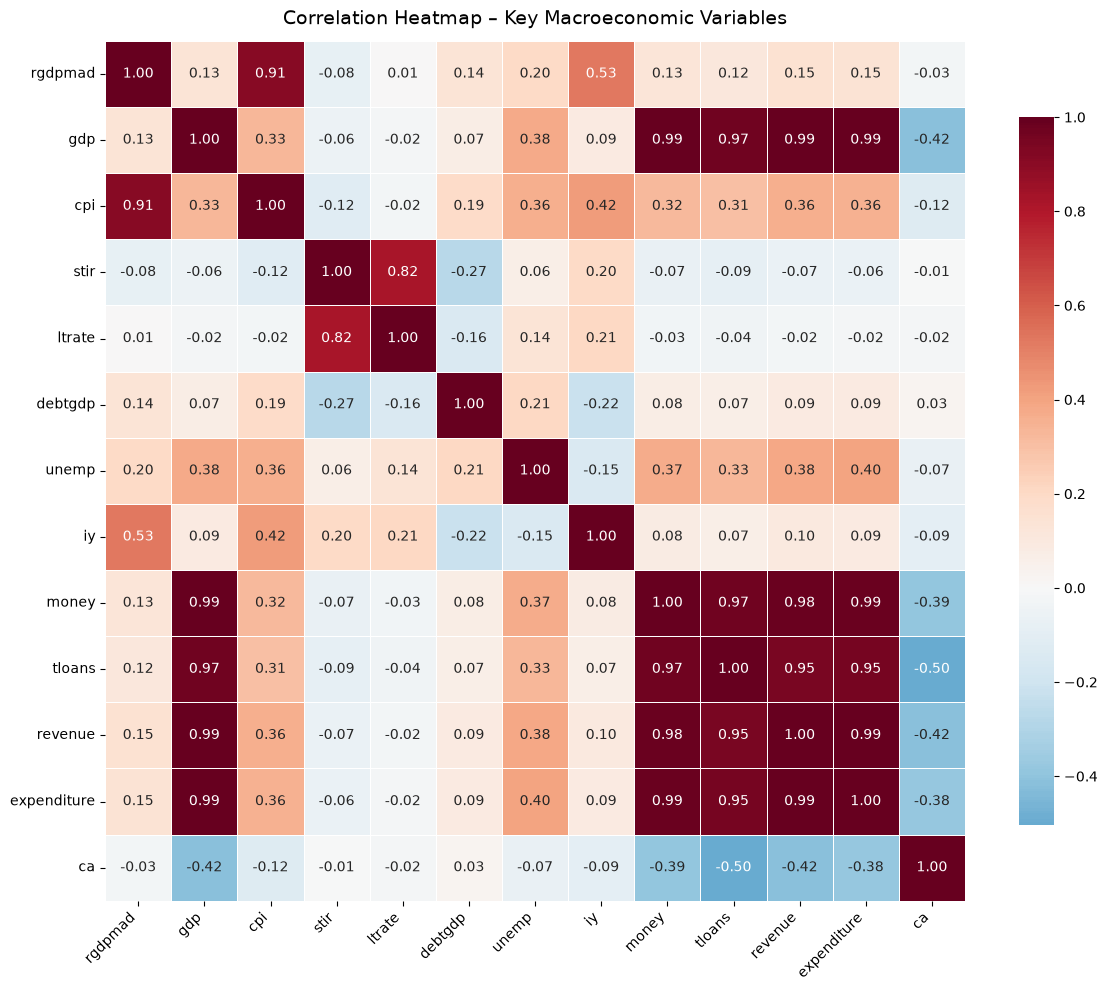

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase3\figures\correlation_heatmap.png

Cell 3 completed successfully.


In [4]:
# Phase 3 – Exploratory Data Analysis
# Cell 3: Correlation Analysis + Heatmap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_FIG = PROJECT / "outputs" / "phase3" / "figures"
OUT_TAB = PROJECT / "outputs" / "phase3" / "tables"

df = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "jst_final_clean.pkl")

print("=" * 60)
print("Phase 3 – EDA | Cell 3: Correlation Analysis")
print("=" * 60)

# Key variables for correlation
corr_vars = [
    "rgdpmad", "gdp", "cpi", "stir", "ltrate",
    "debtgdp", "unemp", "iy", "money", "tloans",
    "revenue", "expenditure", "ca"
]
corr_vars = [v for v in corr_vars if v in df.columns]

# Correlation matrix
corr_matrix = df[corr_vars].corr()

print("\n--- Correlation Matrix ---")
print(corr_matrix.round(3))

corr_matrix.to_csv(OUT_TAB / "correlation_matrix.csv")
print(f"\nSaved correlation matrix → {OUT_TAB / 'correlation_matrix.csv'}")

# ---------------------- Heatmap ----------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap – Key Macroeconomic Variables", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_FIG / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'correlation_heatmap.png'}")

print("\nCell 3 completed successfully.")

Phase 3 – EDA | Cell 4: Trend Analysis


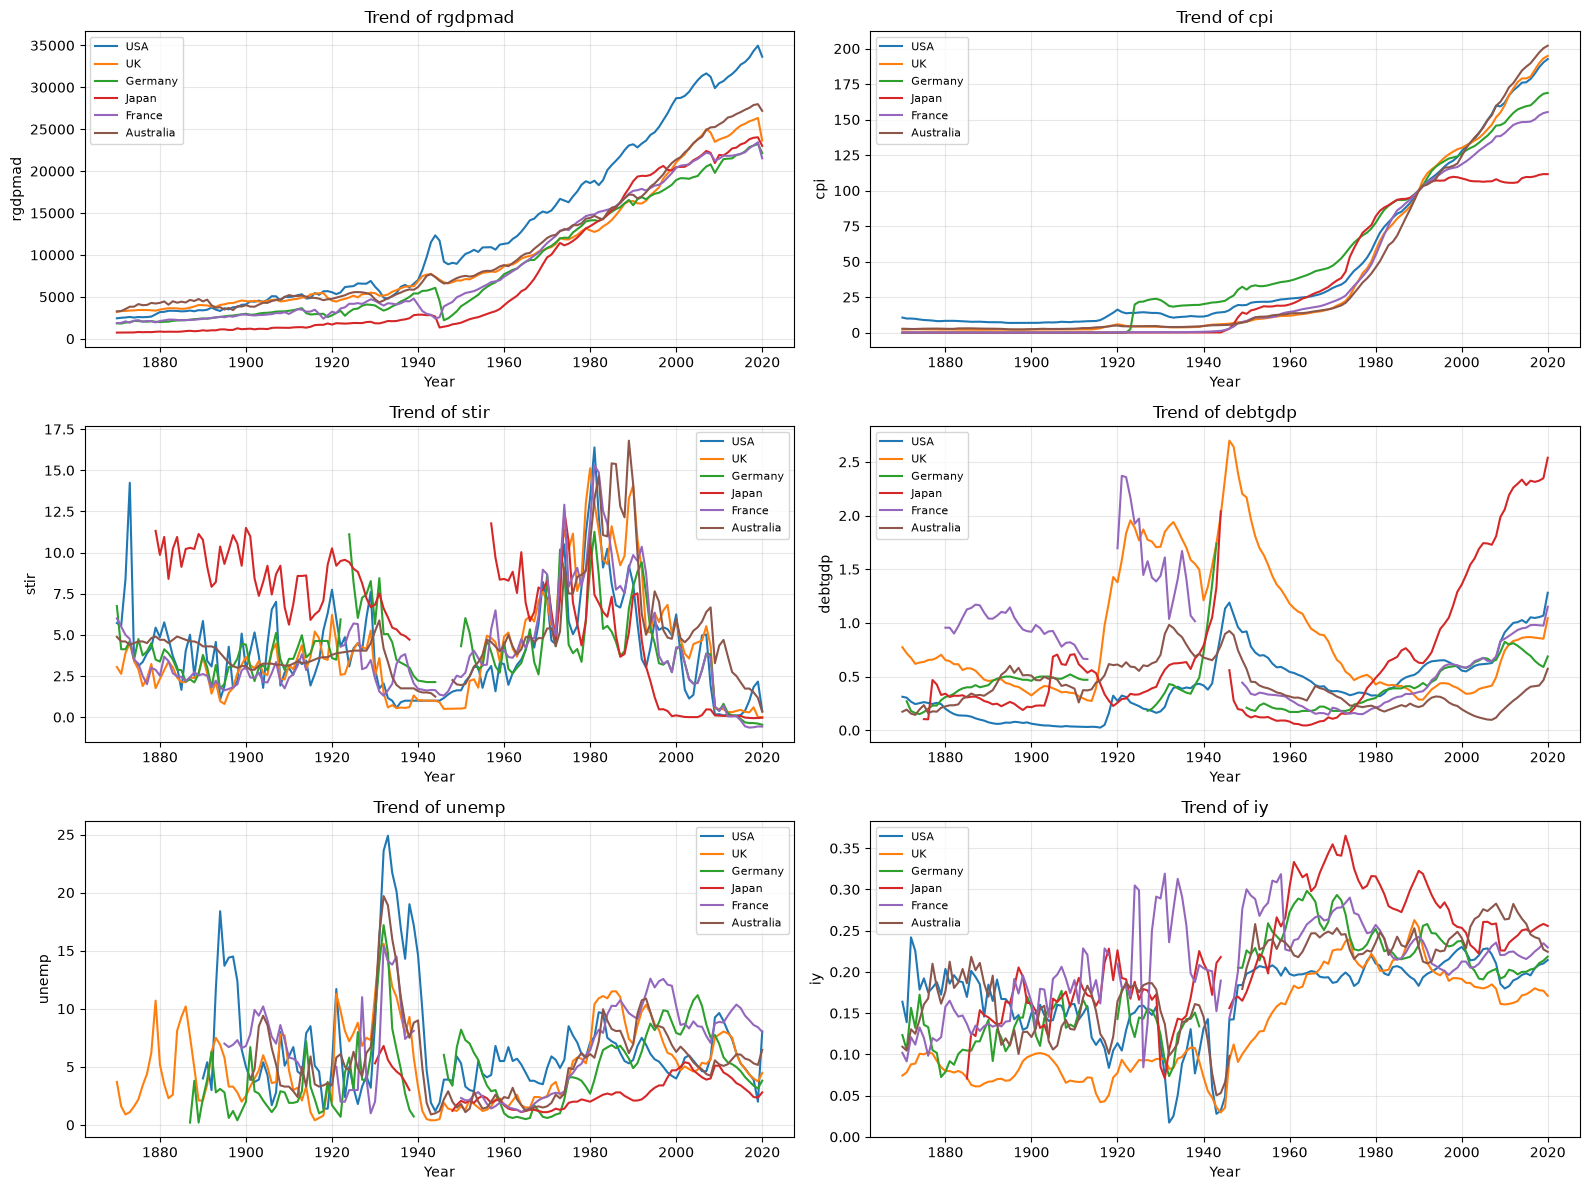

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase3\figures\time_series_trends.png

Cell 4 completed successfully.


In [5]:
# Phase 3 – Exploratory Data Analysis
# Cell 4: Trend Analysis (Time Series Plots)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_FIG = PROJECT / "outputs" / "phase3" / "figures"

df = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "jst_final_clean.pkl")

print("=" * 60)
print("Phase 3 – EDA | Cell 4: Trend Analysis")
print("=" * 60)

# Select a few representative countries for clarity
selected_countries = ["USA", "UK", "Germany", "Japan", "France", "Australia"]

# Key variables to plot trends
trend_vars = ["rgdpmad", "cpi", "stir", "debtgdp", "unemp", "iy"]

df_plot = df[df["country"].isin(selected_countries)].copy()

# ---------------------- Time Series Plots ----------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(trend_vars):
    ax = axes[i]
    for country in selected_countries:
        cdf = df_plot[df_plot["country"] == country].sort_values("year")
        ax.plot(cdf["year"], cdf[var], label=country, linewidth=1.5)
    
    ax.set_title(f"Trend of {var}", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel(var)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG / "time_series_trends.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'time_series_trends.png'}")

print("\nCell 4 completed successfully.")

In [6]:
# Phase 3 – Exploratory Data Analysis
# Cell 5: Anomaly Detection

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import IsolationForest

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase3" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase3" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase3" / "figures"

df = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "jst_final_clean.pkl")

print("=" * 60)
print("Phase 3 – EDA | Cell 5: Anomaly Detection")
print("=" * 60)

# Variables for anomaly detection
anom_vars = ["rgdpmad", "cpi", "stir", "debtgdp", "unemp", "iy", "tloans"]
anom_vars = [v for v in anom_vars if v in df.columns]

# Prepare data (drop rows with any missing in these vars)
df_anom = df[["year", "country"] + anom_vars].dropna().copy()

print(f"Observations used for anomaly detection: {len(df_anom)}")

# Isolation Forest
iso = IsolationForest(contamination=0.03, random_state=42, n_estimators=200)
df_anom["anomaly"] = iso.fit_predict(df_anom[anom_vars])

# -1 = anomaly, 1 = normal
n_anomalies = (df_anom["anomaly"] == -1).sum()
print(f"Number of detected anomalies: {n_anomalies} ({n_anomalies/len(df_anom)*100:.2f}%)")

# Show top anomalies
anomalies = df_anom[df_anom["anomaly"] == -1].sort_values("year")
print("\n--- Sample of Detected Anomalies ---")
print(anomalies[["year", "country"] + anom_vars].head(15).to_string(index=False))

# Save
anomalies.to_csv(OUT_TAB / "detected_anomalies.csv", index=False)
df_anom.to_pickle(OUT_DATA / "data_with_anomaly_flag.pkl")

print(f"\nSaved anomalies → {OUT_TAB / 'detected_anomalies.csv'}")
print(f"Saved full flagged data → {OUT_DATA / 'data_with_anomaly_flag.pkl'}")

print("\nCell 5 completed successfully.")

Phase 3 – EDA | Cell 5: Anomaly Detection
Observations used for anomaly detection: 1758
Number of detected anomalies: 53 (3.01%)

--- Sample of Detected Anomalies ---
 year country      rgdpmad        cpi      stir  debtgdp   unemp       iy       tloans
 1932     USA  4908.365780  11.093447  2.050000 0.327513 23.6000 0.017287 3.447800e+01
 1933     USA  4776.915478  10.526628  1.160000 0.394033 24.9000 0.025232 2.789600e+01
 1945      UK  7056.134561   6.090945  0.900000 2.346864  0.5000 0.035428 1.502900e+00
 1981   Spain  8717.565241  47.032206 15.894667 0.195762 14.2000 0.218492 1.235580e+07
 1982   Spain  8812.166832  53.811346 17.172833 0.243971 16.0000 0.215959 1.433225e+07
 1983   Spain  8934.404835  60.363305 19.452833 0.294779 17.5000 0.207881 1.604088e+07
 1984   Spain  8979.815391  67.171308 12.601750 0.353572 20.2000 0.187281 1.641848e+07
 1985   Spain  9220.500715  73.091999 11.610500 0.402425 21.6400 0.191808 1.793879e+07
 1986   Spain  9563.056583  79.521056 11.490833 0.